**Disaster Risk Score and Pattern Identification**


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('/content/drive/MyDrive/disasterIND.csv')

In [4]:
#Removing the unnecessary columns
df=df.drop(columns=[
    "Reconstruction Costs ('000 US$)",
    "Reconstruction Costs, Adjusted ('000 US$)",
    "Insured Damage ('000 US$)",
    "Insured Damage, Adjusted ('000 US$)",
    'River Basin',
    "AID Contribution ('000 US$)",
    "Latitude",
    "Longitude",
    "River Basin",
    "Admin Units",
    "Event Name",
    "ISO",
    "Country",
    "Subregion",
    "Region"
],axis=1)

In [5]:
df['Magnitude']=df.groupby('Disaster Type')['Magnitude'].transform(lambda x:x.fillna(x.median()))

In [7]:
df['Magnitude']=df['Magnitude'].fillna(0)

In [8]:
df['Location'] = df['Location'].astype(str)
df['Location'] = df['Location'].str.split(',').str[0]

In [14]:
df["Location"] = df["Location"].replace({
    "West Begala": "West Bengal",
    "Western": "West",
    "Balasore":"Odisha",
    "Balasore (Baleshwar)":"Odisha",
    "Orissa":"Odisha",
    "Orissa (Orissa)":"Odisha",
    "Odisha province":"Odisha",
    "Odisha state":"Odisha",
    "Odisha, India":"Odisha",
    "Calcutta":"West Bengal",
    "West Bengal, India":"West Bengal",
    "Bengal":"West Bengal",
    "West Bengal province":"West Bengal",
    "West Bengal state":"West Bengal",
    "W Bengal":"West Bengal"
})

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
columns_req = [
    'Location',
    'Disaster Type',
    'Disaster Subtype',
    'Total Deaths',
    'No. Injured',
    'No. Homeless',
    'Total Affected',
    "Total Damage ('000 US$)",
    'Start Year',
    'Start Month'
]

ndf = df[columns_req].copy()
ndf.fillna(0, inplace=True)

#Encoding the Categorical Columns
ndf['Location_Name'] = ndf['Location']
ndf['Location_Code'] = ndf['Location'].astype('category').cat.codes
ndf['Disaster Type'] = ndf['Disaster Type'].astype('category').cat.codes
ndf['Disaster Subtype'] = ndf['Disaster Subtype'].astype('category').cat.codes

#Calculating frquency
loc_years = ndf.groupby('Location')['Start Year'].agg(['min', 'max', 'count'])
loc_years['years_active'] = loc_years['max'] - loc_years['min'] + 1
loc_years['freq_per_year'] = loc_years['count'] / loc_years['years_active']
ndf['location_frequency'] = ndf['Location'].map(loc_years['freq_per_year'])

# Normalize
ndf['location_frequency'] = ndf['location_frequency'] / ndf['location_frequency'].max()

#Calculating the disaster risk score
ndf['risk_score_raw'] = (
    0.4 * ndf['Total Deaths'] +
    0.3 * ndf['Total Affected'] +
    0.2 * ndf["Total Damage ('000 US$)"] +
    0.1 * ndf['No. Injured']
)
ndf['risk_score_raw'] = ndf['risk_score_raw'] * (1 + ndf['location_frequency'])

# Normalize risk score using MinMax
ndf['risk_score'] = ((ndf['risk_score_raw'] - ndf['risk_score_raw'].min()) /
    (ndf['risk_score_raw'].max() - ndf['risk_score_raw'].min()))

ndf['risk_level'] = pd.qcut(
    ndf['risk_score'],
    3,
    labels=['Low', 'Medium', 'High']
)

ndf_sorted = ndf.sort_values(by='risk_score', ascending=False)

#Applying the KMeans Clustering to group Low,Medium and High risk areas into clusters
features = [
    'Total Deaths',
    'Total Affected',
    "Total Damage ('000 US$)",
    'No. Injured',
    'No. Homeless',
    'location_frequency'
]

X = ndf[features]

#Performing Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
ndf['ml_cluster'] = kmeans.fit_predict(X_scaled)

cluster_order = ndf.groupby('ml_cluster')['risk_score'].mean().sort_values()

cluster_map = {
    cluster_order.index[0]: 'Low',
    cluster_order.index[1]: 'Medium',
    cluster_order.index[2]: 'High'
}

ndf['ml_risk_level'] = ndf['ml_cluster'].map(cluster_map)

risk_level_table = ndf_sorted[
    ['Location_Name', 'risk_score', 'risk_level', 'location_frequency']
]

# Save to CSV
risk_level_table.to_csv("risk_level_table.csv", index=False)

print("Top 10 High Risk Areas:\n")
risk_level_table.head(10)

Top 10 High Risk Areas:



,Location_Name,risk_score,risk_level,location_frequency
434,Uttar Pradesh,1.000000,High,0.428571
648,Tamil Nadu,0.915958,High,0.184783
237,Gujarat,0.777460,High,0.112903
106,Central,0.504703,High,0.083333
76,Nationwide except south,0.356512,High,0.500000
178,districts of Bhiwani,0.349293,High,0.500000
292,Punjab,0.323414,High,0.046875
394,New Delhi city (Delhi province),0.176016,High,0.500000
113,Northwest,0.120425,High,0.500000
423,Barpeta,0.111830,High,0.142857


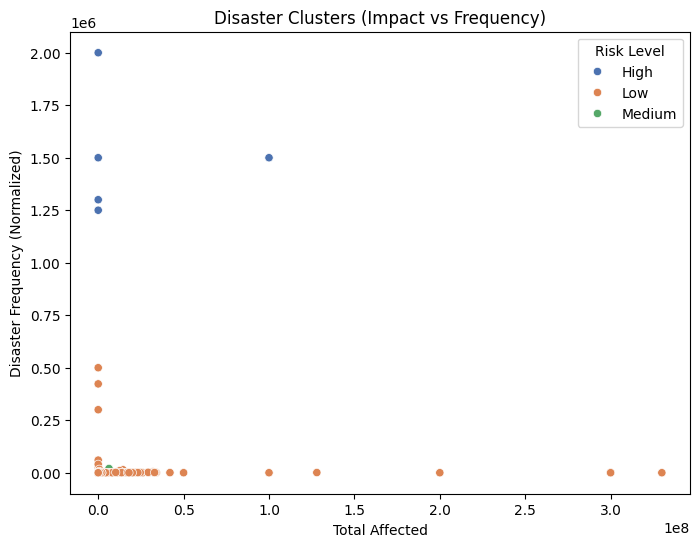

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=ndf['Total Affected'],
    y=ndf['Total Deaths'],
    hue=ndf['ml_risk_level'],   # cluster labels
    palette='deep'
)

plt.xlabel("Total Affected")
plt.ylabel("Disaster Frequency (Normalized)")
plt.title("Disaster Clusters (Impact vs Frequency)")
plt.legend(title="Risk Level")

plt.show()